# Figure 6 - Brief analysis of Transcription Factor binding Sites

## Goals:
1. Characterize cell cycle nature of cycling transcription factors, prevelence of PTR
2. Characterize which of these are associated with genes and whether those genes are cell cycle (cross-reference with transcription-story)


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [180]:
from src.transcripts_dataset import load_transcripts_sets

genes, _ = load_transcripts_sets('output/draft4_run/')
gene = genes[genes.gene == 'MCM7'].iloc[0]
gene

gene                         MCM7
chr                             2
cat                          gene
start                      625772
stop                       628309
strand                          +
classification           Verified
length                       2537
rna_called_TSS           625727.0
Park_TSS                 625743.0
Park_PAS                 628475.0
TSS                        625727
PAS                        628475
promoter_start             625427
promoter_end               625727
gene_body_start            625727
gene_body_end              626227
transcript_class            genic
full_transcript_start      625727
full_transcript_end      628475.0
Name: YBR202W, dtype: object

In [182]:
sites =fig_tfs.binding_sites.all_rossi_tf_dfs
sites[(sites.tf == 'Mcm1') & (sites.chr == gene.chr) & 
    (sites.start > gene.promoter_start)]


,chr,start,end,peakVal,strand,motif,sample_id,replicate,tf
2065,2,625557,625558,1000,+,1,12441,rep1,Mcm1


In [133]:
from src.TranscriptionFactorProcessor import TranscriptionFactorProcessor

fig_tfs = TranscriptionFactorProcessor('output/draft4_run/')

Creating directory: output/draft4_run//figures_transcription_factors...Directory exists. Skipping.
Loading saved data from output/draft4_run//chromatin_metrics...
  Loading deconvolved data...
    Loaded promoter_occupancy: 9663 genes, 257 timepoints
    Loaded nucleosome_entropy: 9663 genes, 257 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 257 timepoints
    Loaded promoter_occupancy PTRs: 9663 genes
    Loaded nucleosome_entropy PTRs: 9663 genes
    Loaded nucleosome_occupancy PTRs: 9663 genes
  Loading raw_rep1 data...
    Loaded promoter_occupancy: 9663 genes, 16 timepoints
    Loaded nucleosome_entropy: 9663 genes, 16 timepoints
    Loaded nucleosome_occupancy: 9663 genes, 16 timepoints
    Loaded promoter_occupancy PTRs: 9663 genes
    Loaded nucleosome_entropy PTRs: 9663 genes
    Loaded nucleosome_occupancy PTRs: 9663 genes
  Loading raw_rep2 data...
    Loaded promoter_occupancy: 9663 genes, 15 timepoints
    Loaded nucleosome_entropy: 9663 genes, 15 timepoints
    

In [134]:
full_results = fig_tfs.build_comprehensive_dataframe(force_recompute=True)

Building comprehensive dataframe with gene associations...
Preparing binding site coordinates...
Prepared 2793 binding sites with ±40bp windows
Computing basic TF binding profiles...
Loading and processing chromatin data...
Processing site 1/2793
Processing site 201/2793
Processing site 401/2793
Processing site 601/2793
Processing site 801/2793
Processing site 1001/2793
Processing site 1201/2793
Processing site 1401/2793
Processing site 1601/2793
Processing site 1801/2793
Processing site 2001/2793
Processing site 2201/2793
Processing site 2401/2793
Processing site 2601/2793
Successfully processed 2793 binding sites
Saved basic results to: output/draft4_run//figures_transcription_factors/binding_results.csv
Calculating peak-to-trough ratios...
Added PTR values (mean: 1.192)
Saved basic results to: output/draft4_run//figures_transcription_factors/binding_results.csv
Saved comprehensive results to: output/draft4_run//figures_transcription_factors/full_results.csv
Comprehensive dataframe c

Number of transcription factors with >20 sites 28
Saved figure to: output/draft4_run//figures_transcription_factors/factor_binding_cyclicity.png


(<Figure size 600x700 with 2 Axes>,
 <Axes: title={'center': 'Cyclicity of transcription factor\nbinding, n=2793, 317 cycling (11%)'}, xlabel='PTR Value', ylabel='Transcription Factor'>,
 Index(['Stb5', 'Gcr1', 'Stb3', 'Ace2', 'Cin5', 'Fhl1', 'Rfx1', 'Ume6', 'Rap1',
        'Pdr1', 'Phd1', 'Sok2', 'Spt15', 'Nhp6A', 'Yrr1', 'Tbf1', 'Sfl1',
        'Fkh2', 'Reb1', 'Mcm1', 'Fkh1', 'Mig1', 'Abf1', 'Bas1', 'Sum1', 'Swi4',
        'Mig2', 'Hap3'],
       dtype='object', name='tf'))

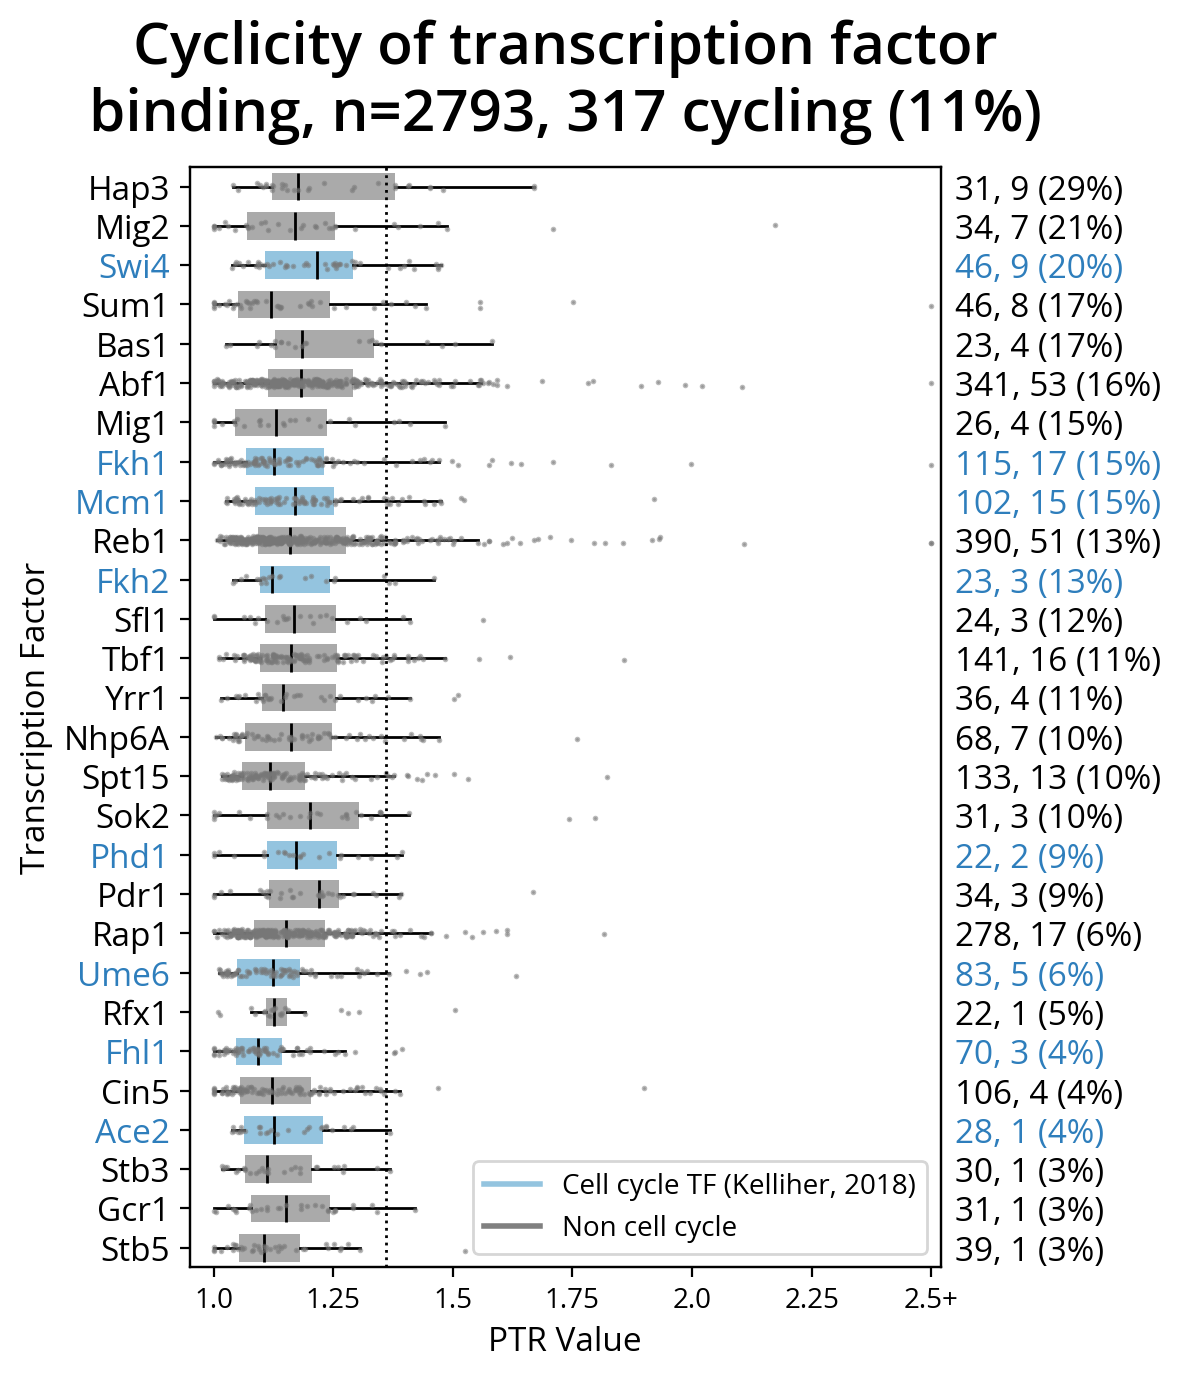

In [135]:
fig_tfs.plot_tf_boxplots()

In [139]:
fig_tfs.classify_genomic_cell_cycle_sites()

In [164]:
fig_tfs.test_cycling_tfs_for_prom_testing()

,p_value,p_adjusted,total_cycling_sites
Rap1,0.030178,0.422497,17.0
Abf1,0.110576,0.762957,53.0
Hap3,0.002423,0.067856,9.0


Saved figure to: output/draft4_run//figures_transcription_factors/binding_locations_both.png


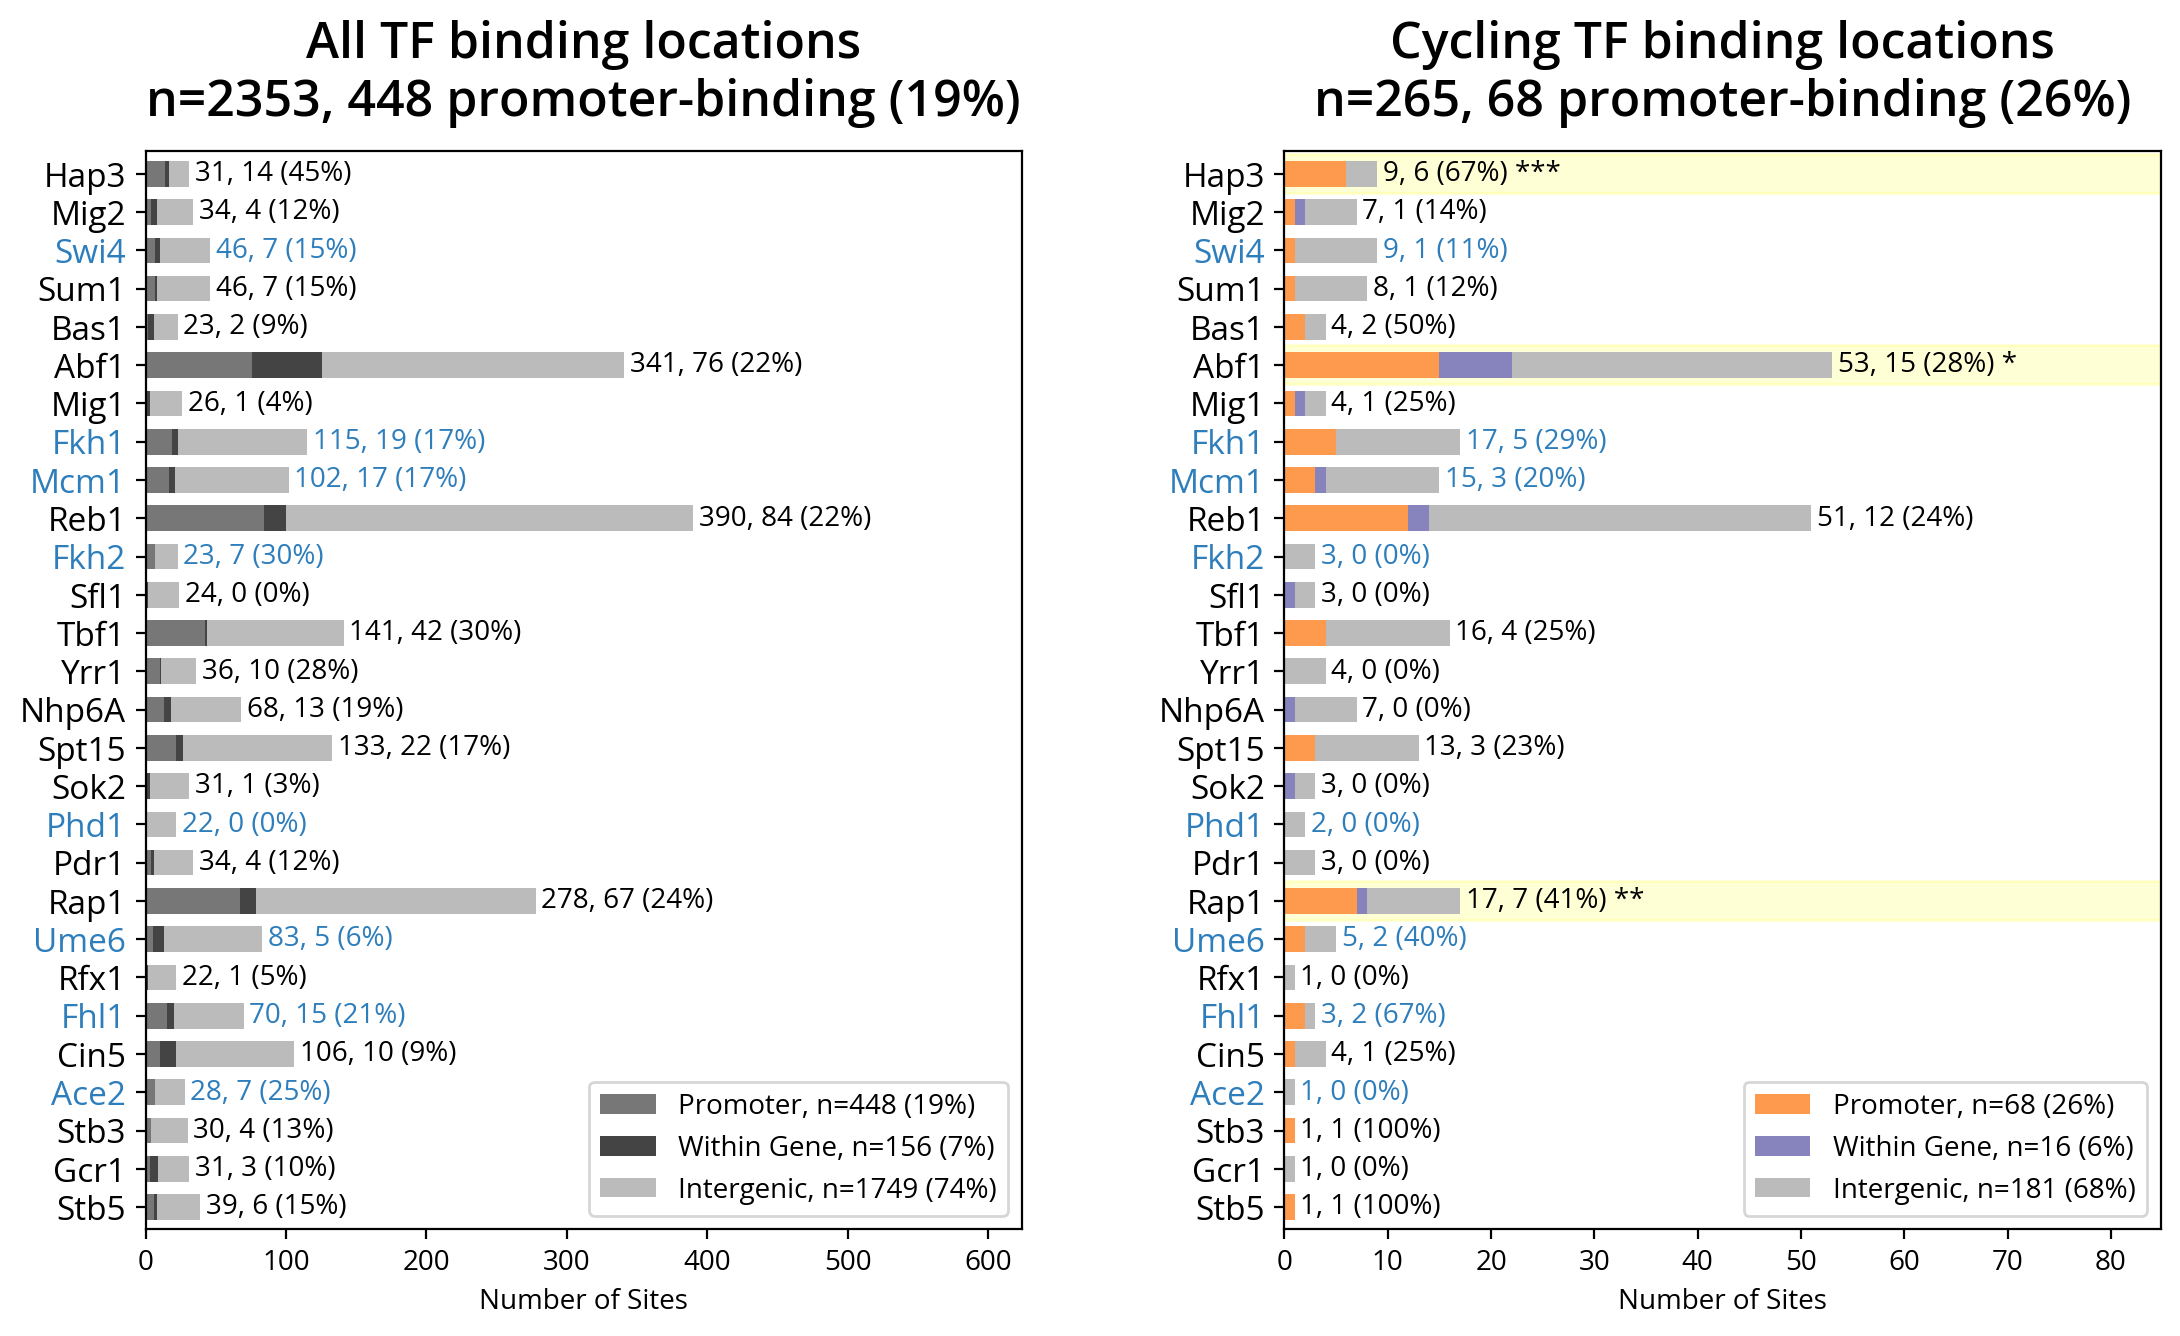

In [165]:
fig_tfs.plot_before_after_genomic_classifications()

Debug figure saved to: output/draft4_run//Figures/Supplemental5.5_Transcription_Factors_debug.png
Clean figure saved to: output/draft4_run//Figures/Supplemental5.5_Transcription_Factors.png


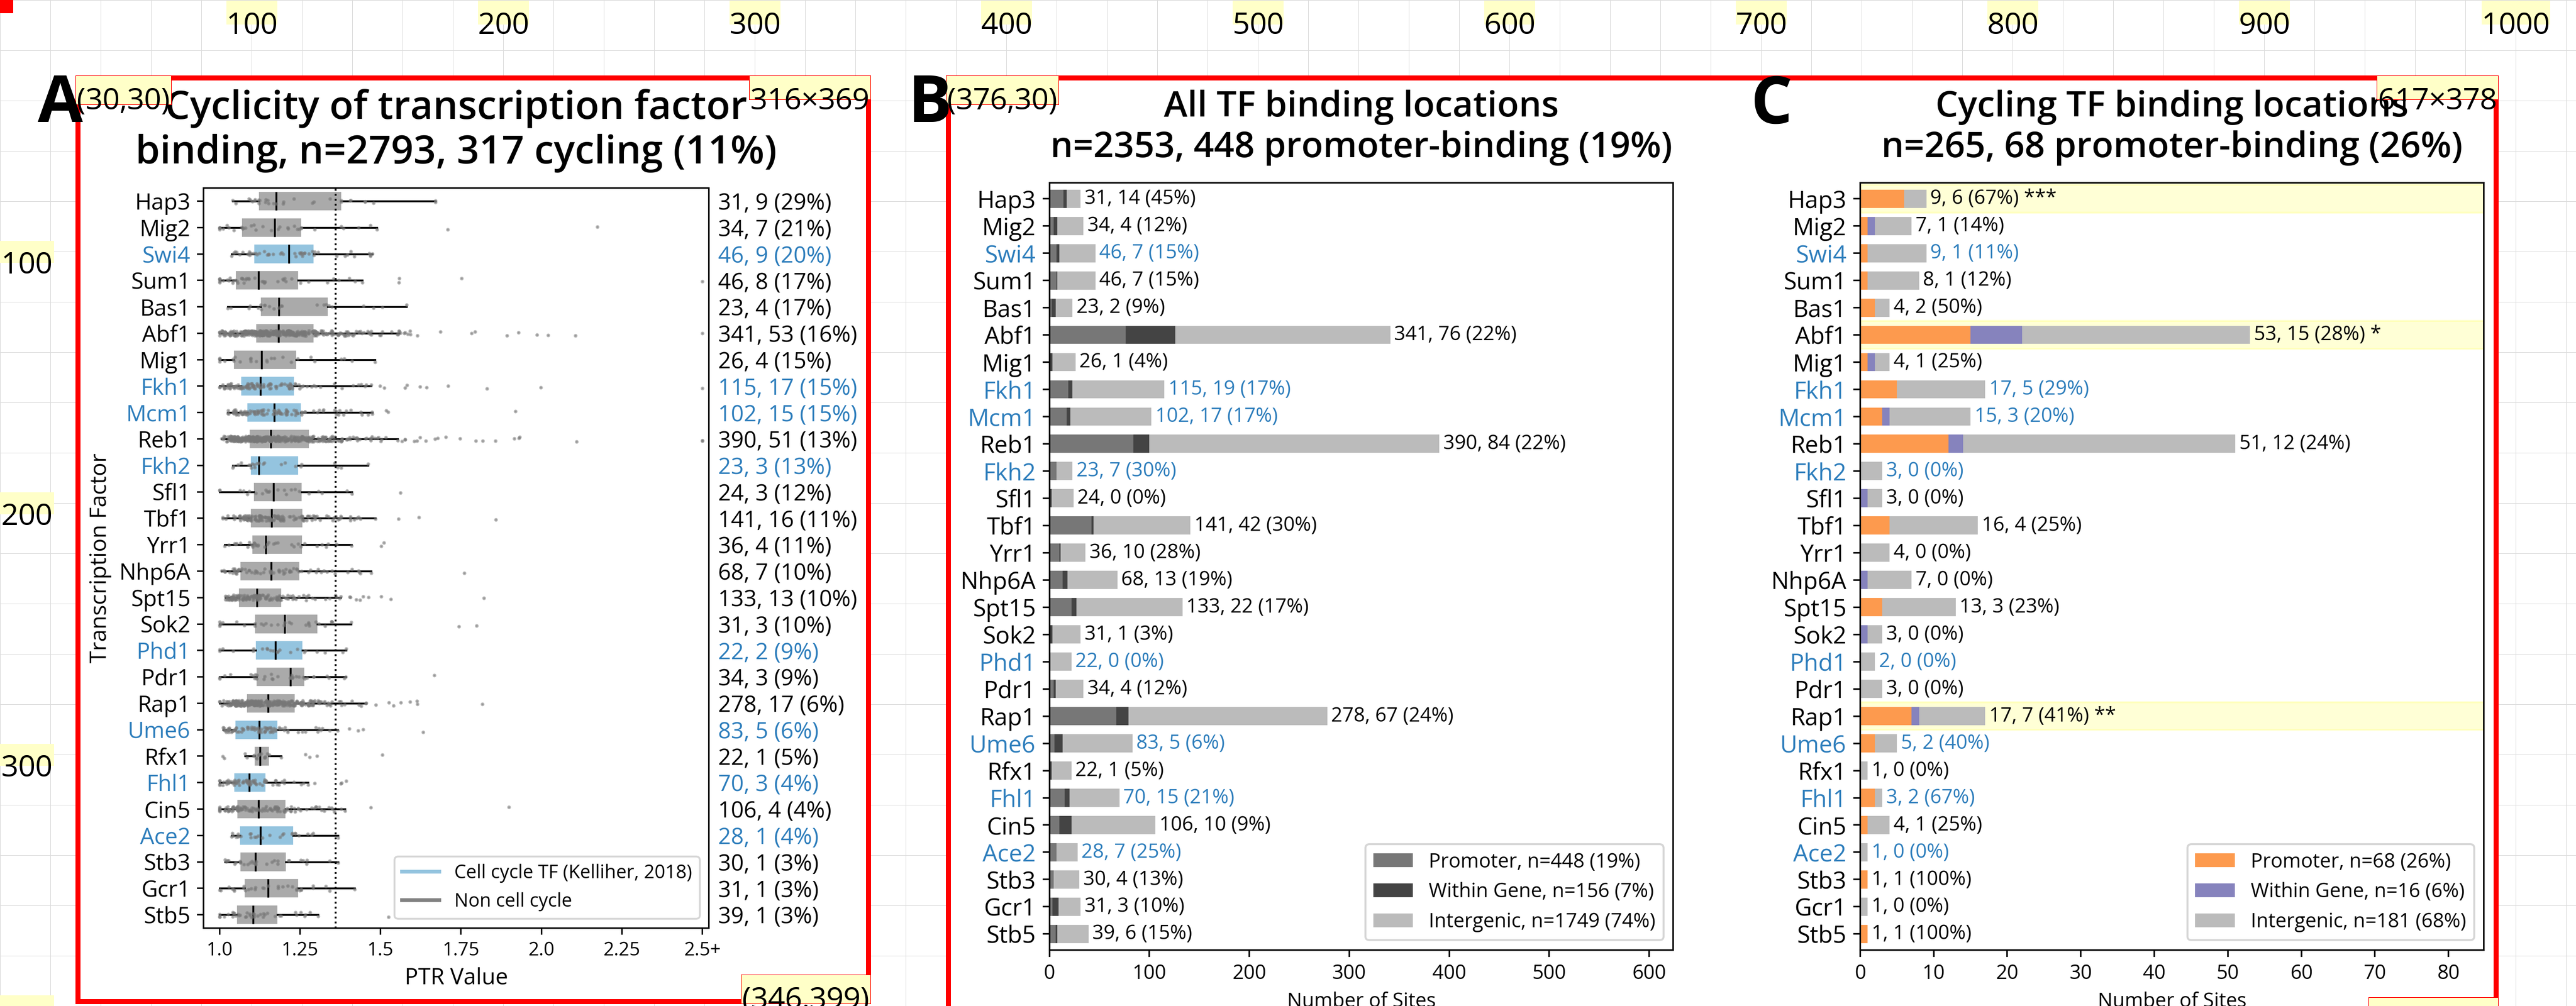

In [166]:
fig_tfs.layout_panel()
from IPython.display import Image, display
display(Image(f'{fig_tfs.output_dir}/Figures/Supplemental5.5_Transcription_Factors_debug.png'))
